<a href="https://colab.research.google.com/github/BasemFakhry1/Artificial_Intelligence__Lab_Assignment/blob/main/Artificial_Intelligence_%E2%80%94_Lab_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Part One — Multi-Agent Systems**

**Task 1** — Basic Agent

In [ ]:
class Agent:
    def __init__ (self, name, location):
        self.name = name
        self.location = location
    def perceive(self, environment):
        return f"{self.name} sees {environment} at {self.location}"
    def act(self):
        return f"{self.name} is moving to deliver the package"
agent1 = Agent("Robot-A", "Warehouse")
agent2 = Agent("Robot-B", "Street 5")
print(agent1.perceive("a package destination"))
print(agent1.act())
print(agent2.perceive("traffic"))
print(agent2.act())

Robot-A sees a package destination at Warehouse
Robot-A is moving to deliver the package
Robot-B sees traffic at Street 5
Robot-B is moving to deliver the package


**Task 2** — Communicating Agent

In [ ]:
class CommunicatingAgent(Agent):
    def __init__(self, name, location):
        super(). __init__(name, location)
        self.inbox = []
    def send_message(self, recipient, message):
        recipient.inbox.append((self.name, message))
    def show_inbox(self):
        for sender, msg in self.inbox:
              print(f"From {sender}:{msg}")
communicatingAgent1 = CommunicatingAgent("Robot-A", "Warehouse")
communicatingAgent2 = CommunicatingAgent("Robot-B", "Street 5")

communicatingAgent1.send_message(
    communicatingAgent2,
    "Package delivered successfully"
)
communicatingAgent2.show_inbox()

From Robot-A:Package delivered successfully


**Task 3** — Multi-Agent Simulation (Rock Paper Scissors)

In [ ]:
import random
class Menu:
    def show_menu(self):
        print("1. Start")
        print("2. Exit")
    def show_result_menu(self):
        print("1. Play Again")
        print("2. Quit")
class Player:
    def __init__(self, name):
        self.name = name
        self.last_choice = ""
    def get_move(self):
      while True:
            move = input(f"{self.name}, enter Rock / Paper / Scissors: ").capitalize()
            if move in ["Rock", "Paper", "Scissors"]:
                self.last_choice = move
                return move
            else:
                print("Invalid input. Try again.")
class Computer(Player):
    def get_move(self):
        move = random.choice(["Rock", "Paper", "Scissors"])
        self.last_choice = move
        print(f"{self.name} chose {move}")
        return move
class Game:
    def __init__(self):
        self.menu = Menu()
        self.player = Player("Player")
        self.computer = Computer("Computer")
    def decide_winner(self, player_move, computer_move):

        if player_move == computer_move:
            return "Draw"
        elif (
            (player_move == "Rock" and computer_move == "Scissors") or
            (player_move == "Scissors" and computer_move == "Paper") or
            (player_move == "Paper" and computer_move == "Rock")
        ):
              return "Player Wins"
        else:
            return "Computer Wins"
    def play_round(self):
        player_move = self.player.get_move()
        computer_move = self.computer.get_move()
        result = self.decide_winner(player_move, computer_move)
        print(f"\nResult: {result}")
    def run(self):
        while True:
            self.menu.show_menu()
            choice = input("Choose: ")
            if choice == "1":
                for i in range(3):
                    print(f"\n--- Round {i+1} ---")
                    self.play_round()
                self.menu.show_result_menu()
                again = input("Choose: ")
                if again == "2":
                    print("Goodbye!")
                    break
            elif choice == "2":
                print("Goodbye!")
                break
            else:
                print("Invalid choice.")
game = Game()
game.run()


1. Start
2. Exit
Choose: 1

--- Round 1 ---
Player, enter Rock / Paper / Scissors: paper
Computer chose Rock

Result: Player Wins

--- Round 2 ---
Player, enter Rock / Paper / Scissors: rock
Computer chose Rock

Result: Draw

--- Round 3 ---
Player, enter Rock / Paper / Scissors: rock
Computer chose Scissors

Result: Player Wins
1. Play Again
2. Quit
Choose: 2
Goodbye!


**Part Two — Artificial Neural Networks**

**Task 1** — Load and Explore the Data

In [ ]:
from sklearn.datasets import load_digits
import pandas as pd
digits = load_digits()
df = pd.DataFrame(digits.data)
df['target'] = digits.target
print(df.head())
print(df.shape)
# Samples = 1797
# Features = 64

     0    1    2     3     4     5    6    7    8    9  ...   55   56   57  \
0  0.0  0.0  5.0  13.0   9.0   1.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
1  0.0  0.0  0.0  12.0  13.0   5.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
2  0.0  0.0  0.0   4.0  15.0  12.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
3  0.0  0.0  7.0  15.0  13.0   1.0  0.0  0.0  0.0  8.0  ...  0.0  0.0  0.0   
4  0.0  0.0  0.0   1.0  11.0   0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   

    58    59    60    61   62   63  target  
0  6.0  13.0  10.0   0.0  0.0  0.0       0  
1  0.0  11.0  16.0  10.0  0.0  0.0       1  
2  0.0   3.0  11.0  16.0  9.0  0.0       2  
3  7.0  13.0  13.0   9.0  0.0  0.0       3  
4  0.0   2.0  16.0   4.0  0.0  0.0       4  

[5 rows x 65 columns]
(1797, 65)


**Task 2** — Split the Data

In [ ]:
from sklearn.model_selection import train_test_split
X = digits.data
y = digits.target
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1437, 64)
X_test shape: (360, 64)


**Task 3** — Build the Neural Network

In [ ]:
# The output layer has 10 neurons because there are 10 digit classes (0–9)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model = Sequential()
model.add(Dense(16, activation='relu', input_shape=(64,)))
model.add(Dense(10, activation='softmax'))
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,210 (4.73 KB)

 Trainable params: 1,210 (4.73 KB)

 Non-trainable params: 0 (0.00 B)

**Task 4** — Train and Evaluate

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=8,
    validation_split=0.2
)
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

Epoch 1/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1958 - loss: 3.5379 - val_accuracy: 0.3333 - val_loss: 1.9325
Epoch 2/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3664 - loss: 1.7799 - val_accuracy: 0.4688 - val_loss: 1.4803
Epoch 3/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4917 - loss: 1.4492 - val_accuracy: 0.5764 - val_loss: 1.2094
Epoch 4/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6057 - loss: 1.1715 - val_accuracy: 0.6528 - val_loss: 0.9868
Epoch 5/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6849 - loss: 0.9534 - val_accuracy: 0.7535 - val_loss: 0.7919
Epoch 6/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7520 - loss: 0.7749 - val_accuracy: 0.7708 - val_loss: 0.6451
Epoch 7/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8033 - loss: 0.6240 - val_accuracy: 0.8160 - val_loss: 0.5312
Epoch 8/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8494 - loss: 0.4997 - val_accuracy: 0.

**Task 5** — Plot Training Accuracy

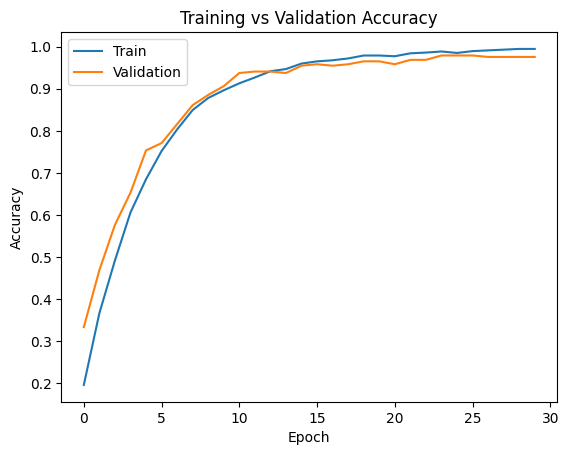

In [ ]:
# There is a small gap between training and validation accuracy,
# which indicates slight overfitting, but the model generalizes well.
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()